# Data Skills Beyond Data Jobs: Exploring Career Opportunities Across U.S. States Using BLS Data


## Background

**Dataset Source**: This project uses the May 2024 State Occupational Employment and Wage Estimates dataset published by the U.S. Bureau of Labor Statistics (BLS). The dataset reports employment levels, wages, job density, and location quotient for occupations across U.S. states and state-level areas.

The original question behind this project is practical: if someone has data analysis skills, where can those skills lead besides a job title that directly says "data analyst"? The BLS dataset does not measure skills directly, but it does give a broad view of occupations where data-related work often appears in business, technology, research, operations, purchasing, logistics, and management settings.


## Objective

As a job seeker with data skills, I do not want the analysis to be limited to a narrow list of traditional data jobs. Many roles use data in a regular and meaningful way even when the job title is not centered on data. For example, a logistics role may use data to monitor inventory and shipping patterns, while a management analyst role may use data to improve business decisions.

For this final version, I organize selected occupations into three groups:

- **Core Data Jobs**: roles where data work is the main focus, such as data scientists, database roles, statisticians, and operations research analysts.
- **Data-Adjacent Jobs**: roles where data is a major part of decision-making or technical work, such as systems analysts, information security analysts, management analysts, and market research analysts.
- **Data-Applicable Jobs**: roles where data skills can be useful in daily work, even though the role is not mainly a data job. This includes operations, logistics, facilities, purchasing, retail supervision, transportation, property management, and related business roles.

The goal is to compare these categories by job volume, wage outcomes, job density, and state-level patterns. Instead of only asking where the highest-paying data jobs are, this project asks a broader question: which job categories and states may give people with data skills more realistic options?


## Analytical Approach

The analysis starts by cleaning the BLS data, converting employment and wage columns into numeric values, and keeping detailed occupation rows. Then, occupation titles are filtered and grouped into the three job categories.

After the categories are built, the project compares them from several angles:

- total employment, to understand how large each job market is;
- employment-weighted wage measures, to avoid giving small occupations the same influence as large occupations;
- job density and location quotient, to understand local concentration;
- state-level rankings, to see where each category is strongest;
- practical job-search takeaways, including specific occupations and less obvious states.

Because this is the final version of the project, the code also uses reusable helper functions for cleaning and weighted summaries. This makes the results more consistent across the category, occupation, and state comparisons.


## Metrics and Fields

The project mainly uses these fields from the BLS dataset:

- **OCC_TITLE**: occupation title
- **AREA_TITLE** and **PRIM_STATE**: state or area information
- **O_GROUP**: occupation group level, used to keep detailed occupations
- **TOT_EMP**: total employment
- **JOBS_1000**: jobs per 1,000 jobs in the state economy
- **LOC_QUOTIENT**: local concentration compared with the national average
- **A_MEDIAN**: median annual wage
- **A_PCT10**: 10th percentile annual wage, used as a lower-end wage measure

For grouped wage results, the project uses employment-weighted averages of occupational wage values. This is not the same as calculating a true worker-level median from raw individual wage records, but it is a better summary for this dataset than treating every occupation-state row equally.


## Setup

Import libraries and load the dataset.


In [1]:
import os
from pathlib import Path

# Make matplotlib use a writable cache directory in this environment.
os.environ['MPLCONFIGDIR'] = '/tmp/matplotlib-cache'
Path(os.environ['MPLCONFIGDIR']).mkdir(parents=True, exist_ok=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (10, 6)

def comma_format(x, pos):
    return f'{x:,.0f}'

DATA_PATH = Path('data/state_M2024_dl.xlsx')
print('Dataset exists:', DATA_PATH.exists())

df = pd.read_excel(DATA_PATH, sheet_name='state_M2024_dl')
print('Dataset shape:', df.shape)

df.head()


Dataset exists: True


Dataset shape: (37609, 32)


,AREA,AREA_TITLE,AREA_TYPE,PRIM_STATE,NAICS,NAICS_TITLE,I_GROUP,OWN_CODE,OCC_CODE,OCC_TITLE,...,H_MEDIAN,H_PCT75,H_PCT90,A_PCT10,A_PCT25,A_MEDIAN,A_PCT75,A_PCT90,ANNUAL,HOURLY
0,1,Alabama,2,AL,0,Cross-industry,cross-industry,1235,00-0000,All Occupations,...,21.07,30.82,47.51,23520,30660,43830,64110,98810,NaN,NaN
1,1,Alabama,2,AL,0,Cross-industry,cross-industry,1235,11-0000,Management Occupations,...,48.39,68.5,98.03,51100,72870,100640,142480,203900,NaN,NaN
2,1,Alabama,2,AL,0,Cross-industry,cross-industry,1235,11-1011,Chief Executives,...,79.04,106.69,#,104950,130950,164400,221910,#,NaN,NaN
3,1,Alabama,2,AL,0,Cross-industry,cross-industry,1235,11-1021,General and Operations Managers,...,51.12,78.26,#,50410,74720,106330,162780,#,NaN,NaN
4,1,Alabama,2,AL,0,Cross-industry,cross-industry,1235,11-1031,Legislators,...,*,*,*,18270,20950,26990,41760,63900,True,NaN


## Part 1: Data Preparation
This section prepares the dataset for category comparison and state analysis.


### Q1. Which columns need type conversion?
Check the structure of the dataset and identify columns that should be numeric.


In [2]:
numeric_columns = [
    'AREA', 'AREA_TYPE', 'NAICS', 'OWN_CODE', 'TOT_EMP', 'EMP_PRSE', 'JOBS_1000',
    'LOC_QUOTIENT', 'PCT_TOTAL', 'PCT_RPT', 'H_MEAN', 'A_MEAN', 'MEAN_PRSE',
    'H_PCT10', 'H_PCT25', 'H_MEDIAN', 'H_PCT75', 'H_PCT90', 'A_PCT10',
    'A_PCT25', 'A_MEDIAN', 'A_PCT75', 'A_PCT90'
]

print(df.dtypes)

AREA              int64
AREA_TITLE       object
AREA_TYPE         int64
PRIM_STATE       object
NAICS             int64
NAICS_TITLE      object
I_GROUP          object
OWN_CODE          int64
OCC_CODE         object
OCC_TITLE        object
O_GROUP          object
TOT_EMP          object
EMP_PRSE         object
JOBS_1000        object
LOC_QUOTIENT     object
PCT_TOTAL       float64
PCT_RPT         float64
H_MEAN           object
A_MEAN           object
MEAN_PRSE        object
H_PCT10          object
H_PCT25          object
H_MEDIAN         object
H_PCT75          object
H_PCT90          object
A_PCT10          object
A_PCT25          object
A_MEDIAN         object
A_PCT75          object
A_PCT90          object
ANNUAL           object
HOURLY           object
dtype: object


### Q2. Are there missing or invalid values?
Find missing values and special values such as `*`, `**`, and `#`.


In [3]:
special_tokens = ['*', '**', '#']
invalid_counts = {
    col: df[col].astype(str).isin(special_tokens).sum()
    for col in numeric_columns
    if df[col].dtype == 'object'
}

missing_summary = pd.DataFrame({
    'missing_values': df.isna().sum(),
    'special_tokens': pd.Series(invalid_counts)
}).fillna(0).astype(int).sort_values(['missing_values', 'special_tokens'], ascending=False)

print(missing_summary.head(12).to_string())

           missing_values  special_tokens
PCT_RPT             37609               0
PCT_TOTAL           37609               0
HOURLY              37447               0
ANNUAL              34943               0
H_PCT90                 0            4310
H_PCT75                 0            3830
H_MEDIAN                0            3561
H_PCT25                 0            3277
H_MEAN                  0            3128
H_PCT10                 0            3128
A_PCT90                 0            1932
A_PCT75                 0            1365


### Q3. How can numeric columns be cleaned in a reusable way?
Create one cleaning function and apply it across employment and wage columns.


In [4]:
def clean_numeric(series):
    cleaned = series.astype(str).str.replace(',', '', regex=False).str.strip()
    cleaned = cleaned.mask(cleaned.isin(['*', '**', '#', 'nan']))
    return pd.to_numeric(cleaned, errors='coerce')


def weighted_average(data, value_col, weight_col='TOT_EMP'):
    valid = data[[value_col, weight_col]].dropna()
    valid = valid[valid[weight_col] > 0]
    if valid.empty:
        return np.nan
    return np.average(valid[value_col], weights=valid[weight_col])


def summarize_weighted(data, group_cols, include_density=False):
    if isinstance(group_cols, str):
        group_cols = [group_cols]

    rows = []
    for keys, group in data.groupby(group_cols, dropna=False):
        if not isinstance(keys, tuple):
            keys = (keys,)
        row = dict(zip(group_cols, keys))
        row['TOT_EMP'] = group['TOT_EMP'].sum(min_count=1)
        row['A_MEDIAN'] = weighted_average(group, 'A_MEDIAN')
        row['A_PCT10'] = weighted_average(group, 'A_PCT10')
        if include_density:
            row['JOBS_1000'] = group['JOBS_1000'].sum(min_count=1)
            row['LOC_QUOTIENT'] = weighted_average(group, 'LOC_QUOTIENT')
        rows.append(row)

    return pd.DataFrame(rows)


df_clean = df.copy()
for col in numeric_columns:
    df_clean[col] = clean_numeric(df_clean[col])

# These two columns are completely empty in this file.
df_clean = df_clean.drop(columns=['PCT_TOTAL', 'PCT_RPT'])
analysis_df = df_clean[df_clean['O_GROUP'] == 'detailed'].copy()

print(analysis_df.shape)
analysis_df.head()


(36367, 30)


,AREA,AREA_TITLE,AREA_TYPE,PRIM_STATE,NAICS,NAICS_TITLE,I_GROUP,OWN_CODE,OCC_CODE,OCC_TITLE,...,H_MEDIAN,H_PCT75,H_PCT90,A_PCT10,A_PCT25,A_MEDIAN,A_PCT75,A_PCT90,ANNUAL,HOURLY
2,1,Alabama,2,AL,0,Cross-industry,cross-industry,1235,11-1011,Chief Executives,...,79.04,106.69,NaN,104950.0,130950.0,164400.0,221910.0,NaN,NaN,NaN
3,1,Alabama,2,AL,0,Cross-industry,cross-industry,1235,11-1021,General and Operations Managers,...,51.12,78.26,NaN,50410.0,74720.0,106330.0,162780.0,NaN,NaN,NaN
4,1,Alabama,2,AL,0,Cross-industry,cross-industry,1235,11-1031,Legislators,...,NaN,NaN,NaN,18270.0,20950.0,26990.0,41760.0,63900.0,True,NaN
5,1,Alabama,2,AL,0,Cross-industry,cross-industry,1235,11-2011,Advertising and Promotions Managers,...,64.22,69.57,72.44,83570.0,86500.0,133570.0,144710.0,150670.0,NaN,NaN
6,1,Alabama,2,AL,0,Cross-industry,cross-industry,1235,11-2021,Marketing Managers,...,54.31,78.64,105.29,65360.0,83940.0,112960.0,163580.0,219000.0,NaN,NaN


## Part 2: Building the Job Category Framework
This section defines the three job categories used in the project.


### Q4. Which occupations should be treated as data-skill jobs?
Use occupation titles to identify roles that involve data skills.


In [5]:
occupation_keywords = [
    'data scientist', 'database', 'statistic', 'operations research',
    'systems analyst', 'security analyst', 'quality assurance analyst',
    'management analyst', 'market research analyst',
    'financial and investment analyst', 'budget analyst', 'credit analyst',
    'actuar', 'survey researcher', 'social science research assistant',
    'data entry', 'facilities manager', 'administrative services manager',
    'logistician', 'shipping', 'inventory', 'transportation, storage',
    'buyers and purchasing', 'purchasing manager', 'procurement',
    'retail sales', 'general and operations manager',
    'business operations specialist', 'property, real estate'
]

keyword_pattern = '|'.join(occupation_keywords)

data_jobs = analysis_df[
    analysis_df['OCC_TITLE'].str.lower().str.contains(keyword_pattern, na=False)
].copy()

print(data_jobs['OCC_TITLE'].nunique())
print(sorted(data_jobs['OCC_TITLE'].drop_duplicates()))

32
['Actuaries', 'Administrative Services Managers', 'Budget Analysts', 'Business Operations Specialists, All Other', 'Buyers and Purchasing Agents', 'Computer Systems Analysts', 'Credit Analysts', 'Data Entry Keyers', 'Data Scientists', 'Database Administrators', 'Database Architects', 'Facilities Managers', 'Financial and Investment Analysts', 'First-Line Supervisors of Non-Retail Sales Workers', 'First-Line Supervisors of Retail Sales Workers', 'General and Operations Managers', 'Information Security Analysts', 'Logisticians', 'Management Analysts', 'Market Research Analysts and Marketing Specialists', 'Operations Research Analysts', 'Procurement Clerks', 'Property, Real Estate, and Community Association Managers', 'Purchasing Managers', 'Retail Salespersons', 'Shipping, Receiving, and Inventory Clerks', 'Social Science Research Assistants', 'Software Quality Assurance Analysts and Testers', 'Statistical Assistants', 'Statisticians', 'Survey Researchers', 'Transportation, Storage, a

### Q5. How should these occupations be grouped into three categories?
Use a dictionary to define Core Data Jobs, Data-Adjacent Jobs, and Data-Applicable Jobs.


In [6]:
job_categories = {
    'Core Data Jobs': [
        'Data Scientists', 'Database Administrators', 'Database Architects',
        'Operations Research Analysts', 'Statisticians', 'Statistical Assistants'
    ],
    'Data-Adjacent Jobs': [
        'Computer Systems Analysts', 'Information Security Analysts',
        'Software Quality Assurance Analysts and Testers', 'Management Analysts',
        'Market Research Analysts and Marketing Specialists',
        'Financial and Investment Analysts', 'Budget Analysts'
    ],
    'Data-Applicable Jobs': [
        'Actuaries', 'Credit Analysts', 'Survey Researchers',
        'Social Science Research Assistants', 'Data Entry Keyers',
        'Facilities Managers', 'Administrative Services Managers',
        'Logisticians', 'Shipping, Receiving, and Inventory Clerks',
        'Transportation, Storage, and Distribution Managers',
        'Buyers and Purchasing Agents', 'Purchasing Managers',
        'Procurement Clerks', 'First-Line Supervisors of Retail Sales Workers',
        'Retail Salespersons', 'General and Operations Managers',
        'Business Operations Specialists, All Other',
        'Property, Real Estate, and Community Association Managers'
    ]
}

print(job_categories)

{'Core Data Jobs': ['Data Scientists', 'Database Administrators', 'Database Architects', 'Operations Research Analysts', 'Statisticians', 'Statistical Assistants'], 'Data-Adjacent Jobs': ['Computer Systems Analysts', 'Information Security Analysts', 'Software Quality Assurance Analysts and Testers', 'Management Analysts', 'Market Research Analysts and Marketing Specialists', 'Financial and Investment Analysts', 'Budget Analysts'], 'Data-Applicable Jobs': ['Actuaries', 'Credit Analysts', 'Survey Researchers', 'Social Science Research Assistants', 'Data Entry Keyers', 'Facilities Managers', 'Administrative Services Managers', 'Logisticians', 'Shipping, Receiving, and Inventory Clerks', 'Transportation, Storage, and Distribution Managers', 'Buyers and Purchasing Agents', 'Purchasing Managers', 'Procurement Clerks', 'First-Line Supervisors of Retail Sales Workers', 'Retail Salespersons', 'General and Operations Managers', 'Business Operations Specialists, All Other', 'Property, Real Estate

### Q6. What does the category structure look like after classification?
Create a summary table showing how many occupations and rows belong to each category.


In [7]:
categorized_jobs = []
for category, titles in job_categories.items():
    subset = analysis_df[analysis_df['OCC_TITLE'].isin(titles)].copy()
    subset['job_category'] = category
    categorized_jobs.append(subset)

jobs_by_category = pd.concat(categorized_jobs, ignore_index=True)

category_summary = jobs_by_category.groupby('job_category').agg(
    rows=('OCC_TITLE', 'size'),
    occupations=('OCC_TITLE', 'nunique'),
    states_covered=('AREA_TITLE', 'nunique')
).reset_index()

print(category_summary.to_string(index=False))

        job_category  rows  occupations  states_covered
      Core Data Jobs   281            6              52
  Data-Adjacent Jobs   369            7              54
Data-Applicable Jobs   918           18              54


## Part 3: Category Comparison
This part compares the three job groups directly.


### Q7. Which category has the largest employment size?
Compare `TOT_EMP` across the three job categories.


In [8]:
employment_by_category = (
    jobs_by_category.groupby('job_category', as_index=False)['TOT_EMP']
    .sum()
    .sort_values('TOT_EMP', ascending=False)
)

print(employment_by_category.to_string(index=False))

        job_category    TOT_EMP
Data-Applicable Jobs 12577900.0
  Data-Adjacent Jobs  3029940.0
      Core Data Jobs   514810.0


### Q8. How can employment by job category be visualized?
Show total employment with a bar chart.


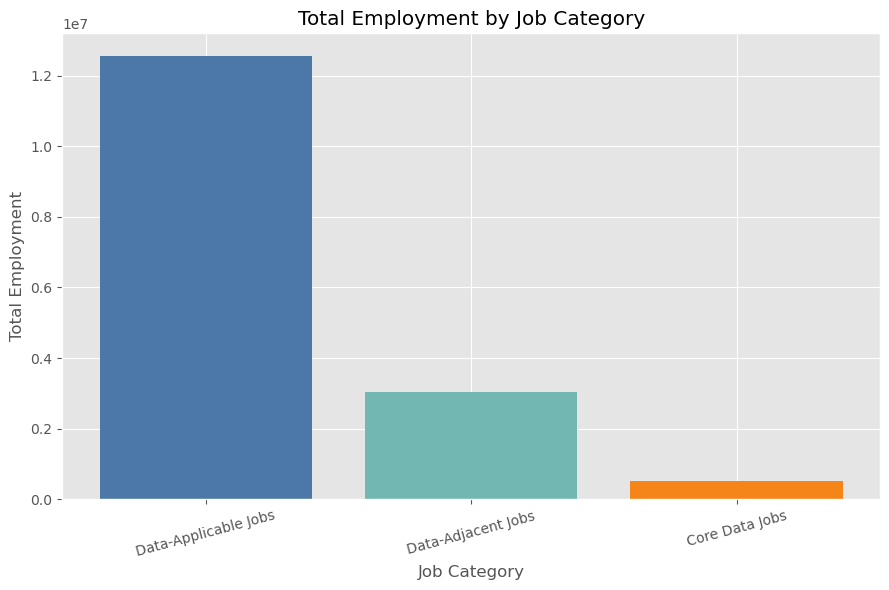

Conclusion:
Data-Applicable Jobs has the most jobs, with 12,577,900 total employment. Core Data Jobs has a much smaller job base, so it looks more limited in this dataset.


In [9]:
plot_df = employment_by_category.copy()

plt.figure(figsize=(9, 6))
plt.bar(plot_df['job_category'], plot_df['TOT_EMP'], color=['#4C78A8', '#72B7B2', '#F58518'])
plt.title('Total Employment by Job Category')
plt.xlabel('Job Category')
plt.ylabel('Total Employment')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

largest = plot_df.iloc[0]
smallest = plot_df.iloc[-1]
print('Conclusion:')
print(
    f"{largest['job_category']} has the most jobs, with {largest['TOT_EMP']:,.0f} total employment. "
    f"{smallest['job_category']} has a much smaller job base, so it looks more limited in this dataset."
)

### Q9. Which category has stronger wage outcomes?
Compare categories using employment-weighted `A_MEDIAN` and `A_PCT10`.


In [10]:
wage_by_category = (
    summarize_weighted(jobs_by_category, 'job_category')
    [['job_category', 'A_MEDIAN', 'A_PCT10']]
    .sort_values('A_MEDIAN', ascending=False)
)

print(wage_by_category.to_string(index=False))


        job_category      A_MEDIAN      A_PCT10
      Core Data Jobs 110333.461683 64570.479583
  Data-Adjacent Jobs  96443.338188 57785.314544
Data-Applicable Jobs  68302.391587 40397.691744


### Q10. How can median and lower-end wages be visualized by category?
Use a grouped bar chart to compare employment-weighted `A_MEDIAN` and `A_PCT10`.


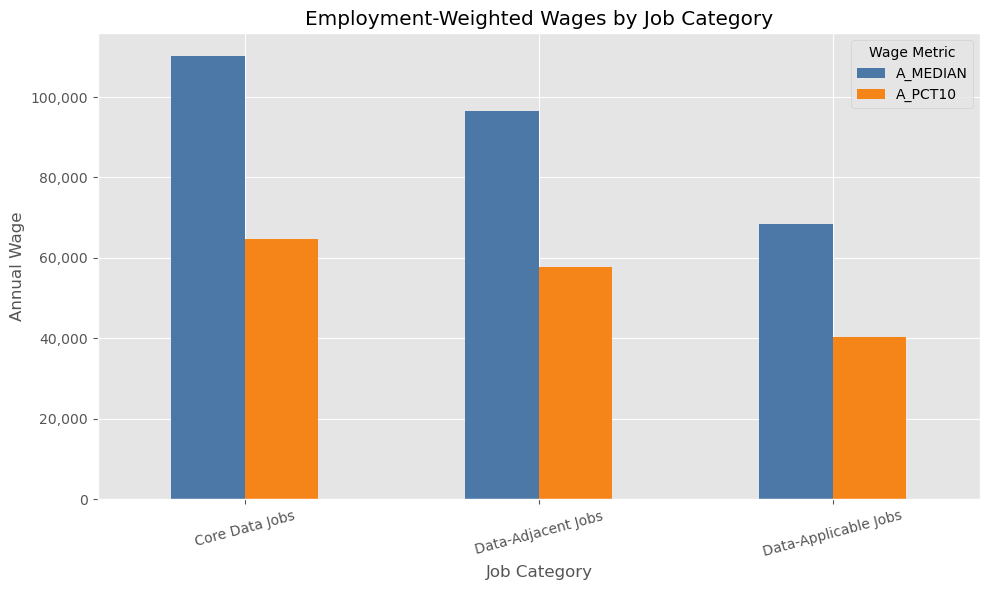

Conclusion:
Core Data Jobs has the highest employment-weighted median wage. Core Data Jobs has the highest employment-weighted 10th percentile wage, so the lower end of pay is also strong in that group.


In [11]:
wage_plot_df = wage_by_category.set_index('job_category')[['A_MEDIAN', 'A_PCT10']]

ax = wage_plot_df.plot(kind='bar', figsize=(10, 6), color=['#4C78A8', '#F58518'])
ax.set_title('Employment-Weighted Wages by Job Category')
ax.set_xlabel('Job Category')
ax.set_ylabel('Annual Wage')
ax.yaxis.set_major_formatter(FuncFormatter(comma_format))
plt.xticks(rotation=15)
plt.legend(title='Wage Metric')
plt.tight_layout()
plt.show()

median_leader = wage_by_category.sort_values('A_MEDIAN', ascending=False).iloc[0]
pct10_leader = wage_by_category.sort_values('A_PCT10', ascending=False).iloc[0]
print('Conclusion:')
print(
    f"{median_leader['job_category']} has the highest employment-weighted median wage. "
    f"{pct10_leader['job_category']} has the highest employment-weighted 10th percentile wage, so the lower end of pay is also strong in that group."
)


### Q11. How does wage distribution vary by category?
Use a boxplot to show how wages vary across the three categories.


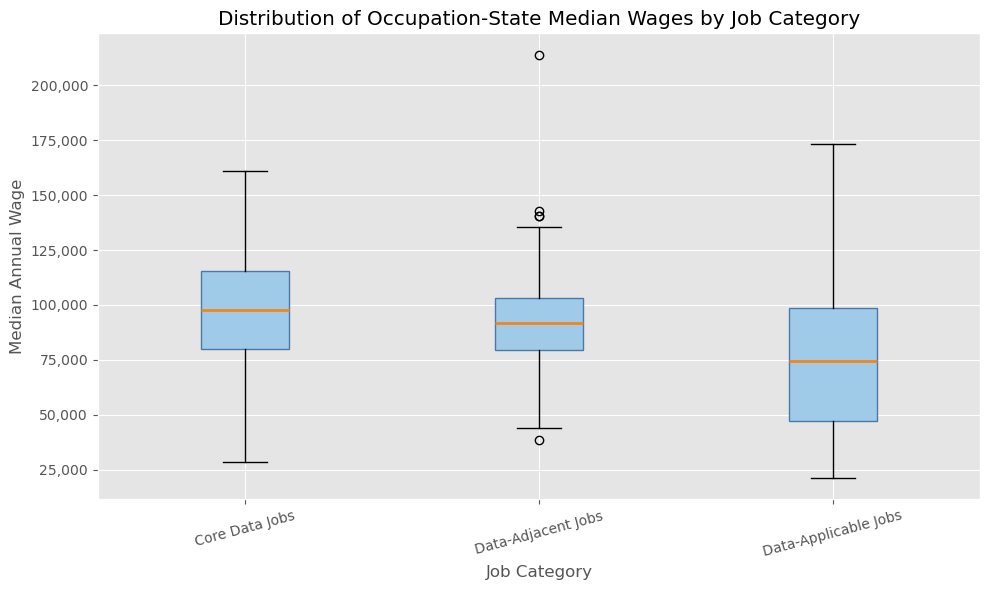

Conclusion:
The wage ranges are different across the three categories. Data-Adjacent Jobs has the smallest wage variation across occupation-state rows in this comparison.


In [12]:
category_order = jobs_by_category.groupby('job_category')['A_MEDIAN'].median().sort_values(ascending=False).index.tolist()
box_data = [
    jobs_by_category.loc[jobs_by_category['job_category'] == category, 'A_MEDIAN'].dropna()
    for category in category_order
]

plt.figure(figsize=(10, 6))
plt.boxplot(box_data, patch_artist=True,
            boxprops=dict(facecolor='#A0CBE8', color='#4C78A8'),
            medianprops=dict(color='#F58518', linewidth=2))
plt.title('Distribution of Occupation-State Median Wages by Job Category')
plt.xlabel('Job Category')
plt.ylabel('Median Annual Wage')
plt.gca().yaxis.set_major_formatter(FuncFormatter(comma_format))
plt.xticks(range(1, len(category_order) + 1), category_order, rotation=15)
plt.tight_layout()
plt.show()

spread_summary = jobs_by_category.groupby('job_category')['A_MEDIAN'].agg(['median', 'std']).sort_values('median', ascending=False)
most_consistent = spread_summary['std'].idxmin()
print('Conclusion:')
print(
    f"The wage ranges are different across the three categories. "
    f"{most_consistent} has the smallest wage variation across occupation-state rows in this comparison."
)


### Q12. What trade-offs appear across the three categories?
Compare employment and wages together instead of looking at only one metric.


In [13]:
state_category_summary = summarize_weighted(
    jobs_by_category,
    ['job_category', 'AREA_TITLE'],
    include_density=True
)

category_tradeoff = summarize_weighted(jobs_by_category, 'job_category')
print(category_tradeoff.to_string(index=False))


        job_category    TOT_EMP      A_MEDIAN      A_PCT10
      Core Data Jobs   514810.0 110333.461683 64570.479583
  Data-Adjacent Jobs  3029940.0  96443.338188 57785.314544
Data-Applicable Jobs 12577900.0  68302.391587 40397.691744


### Q13. How can employment and median wage trade-offs be visualized?
Use a scatter plot to show the trade-off between job volume and pay across states and categories.


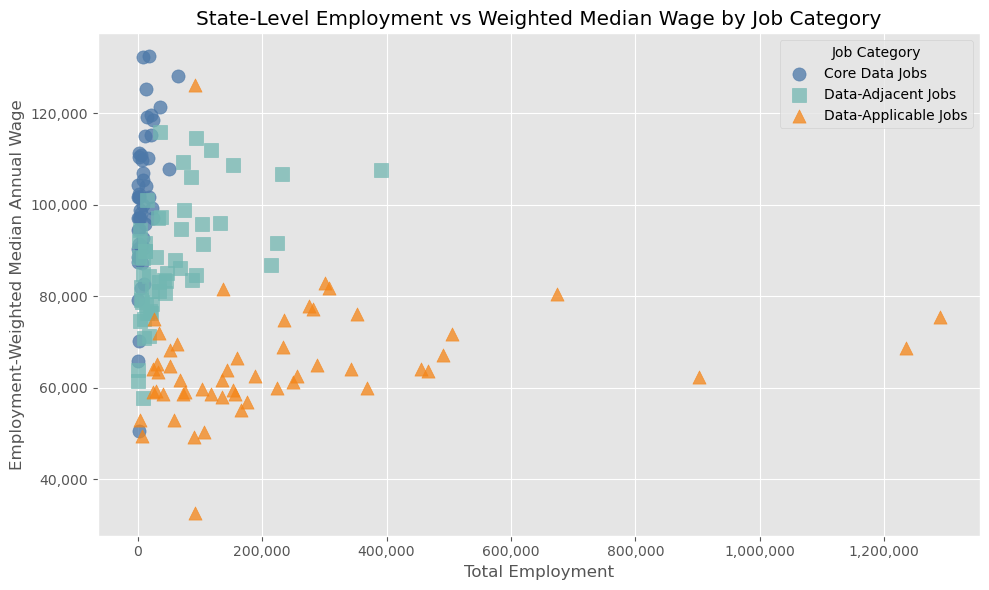

Conclusion:
The scatter plot shows that states with more jobs do not always have the highest wages. The weighted wage view keeps large occupations from being hidden by smaller, high-wage titles.


In [14]:
markers = {'Core Data Jobs': 'o', 'Data-Adjacent Jobs': 's', 'Data-Applicable Jobs': '^'}
colors = {'Core Data Jobs': '#4C78A8', 'Data-Adjacent Jobs': '#72B7B2', 'Data-Applicable Jobs': '#F58518'}

plt.figure(figsize=(10, 6))
for category, group in state_category_summary.groupby('job_category'):
    plt.scatter(group['TOT_EMP'], group['A_MEDIAN'], label=category,
                marker=markers.get(category, 'o'), color=colors.get(category), s=90, alpha=0.75)

plt.title('State-Level Employment vs Weighted Median Wage by Job Category')
plt.xlabel('Total Employment')
plt.ylabel('Employment-Weighted Median Annual Wage')
plt.gca().xaxis.set_major_formatter(FuncFormatter(comma_format))
plt.gca().yaxis.set_major_formatter(FuncFormatter(comma_format))
plt.legend(title='Job Category')
plt.tight_layout()
plt.show()

print('Conclusion:')
print(
    'The scatter plot shows that states with more jobs do not always have the highest wages. '
    'The weighted wage view keeps large occupations from being hidden by smaller, high-wage titles.'
)


## Part 4: State Analysis as Supporting Evidence
Now use state-level analysis to show where these category opportunities are strongest.


### Q14. Which states have the most jobs within each category?
Compare states inside each category using `TOT_EMP`.


In [15]:
state_category_employment = state_category_summary[['job_category', 'AREA_TITLE', 'TOT_EMP']].copy()

for category in job_categories:
    print(f'\nTop states for {category}:')
    print(
        state_category_employment[state_category_employment['job_category'] == category]
        .sort_values('TOT_EMP', ascending=False)
        .head(5)
        .to_string(index=False)
    )


Top states for Core Data Jobs:
  job_category AREA_TITLE  TOT_EMP
Core Data Jobs California  65120.0
Core Data Jobs      Texas  49420.0
Core Data Jobs   New York  35930.0
Core Data Jobs   Virginia  24710.0
Core Data Jobs    Florida  24520.0

Top states for Data-Adjacent Jobs:
      job_category AREA_TITLE  TOT_EMP
Data-Adjacent Jobs California 391720.0
Data-Adjacent Jobs   New York 231310.0
Data-Adjacent Jobs      Texas 224110.0
Data-Adjacent Jobs    Florida 214770.0
Data-Adjacent Jobs   Virginia 152670.0

Top states for Data-Applicable Jobs:
        job_category AREA_TITLE   TOT_EMP
Data-Applicable Jobs California 1289730.0
Data-Applicable Jobs      Texas 1235900.0
Data-Applicable Jobs    Florida  902050.0
Data-Applicable Jobs   New York  673950.0
Data-Applicable Jobs   Illinois  505040.0


### Q15. How can top employment states be visualized within each category?
Show the top five states in each category.


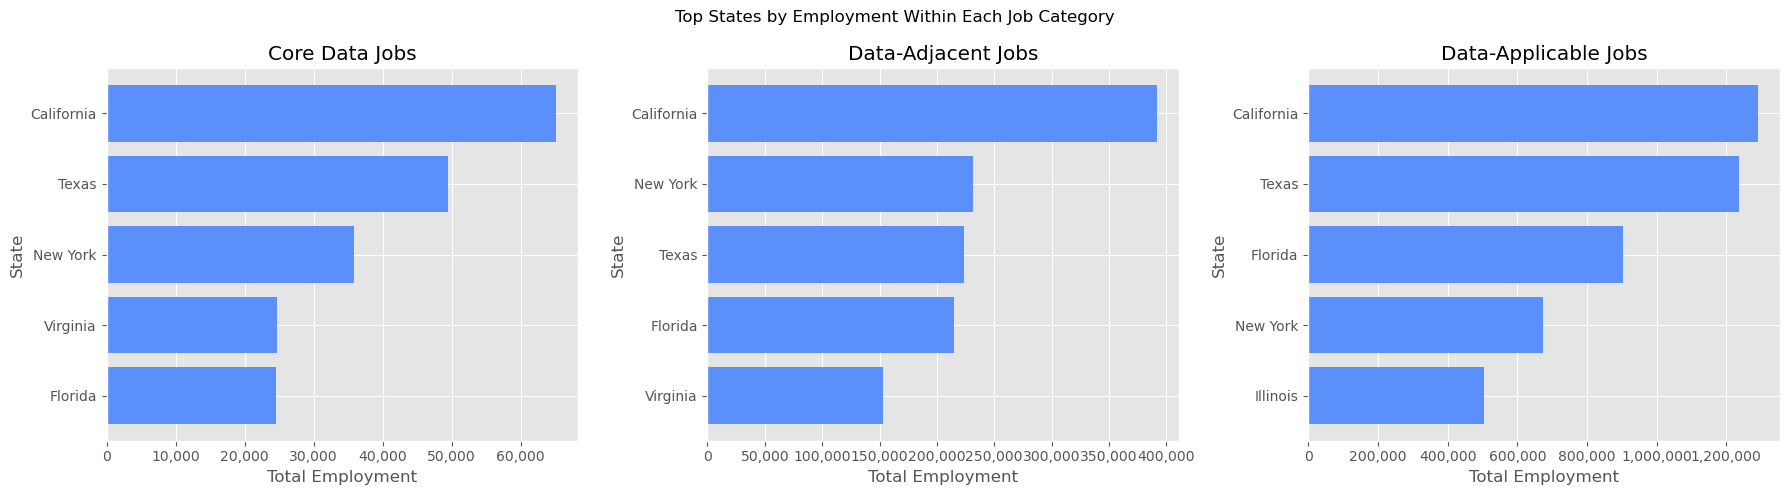

Conclusion:
- California leads Core Data Jobs in employment.
- California leads Data-Adjacent Jobs in employment.
- California leads Data-Applicable Jobs in employment.


In [16]:
top_state_emp = (
    state_category_summary
    .sort_values(['job_category', 'TOT_EMP'], ascending=[True, False])
    .groupby('job_category')
    .head(5)
)

categories = list(job_categories.keys())
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, category in zip(axes, categories):
    subset = top_state_emp[top_state_emp['job_category'] == category].sort_values('TOT_EMP')
    ax.barh(subset['AREA_TITLE'], subset['TOT_EMP'], color='#5B8FF9')
    ax.set_title(category)
    ax.set_xlabel('Total Employment')
    ax.set_ylabel('State')
    ax.xaxis.set_major_formatter(FuncFormatter(comma_format))
fig.suptitle('Top States by Employment Within Each Job Category')
plt.tight_layout()
plt.show()

leaders = top_state_emp.sort_values(['job_category', 'TOT_EMP'], ascending=[True, False]).groupby('job_category').head(1)
print('Conclusion:')
for _, row in leaders.iterrows():
    print(f"- {row['AREA_TITLE']} leads {row['job_category']} in employment.")

### Q16. Which states offer stronger wages within each category?
Compare states within each category using `A_MEDIAN`.


In [17]:
state_category_wages = state_category_summary[['job_category', 'AREA_TITLE', 'A_MEDIAN', 'A_PCT10']].copy()

for category in job_categories:
    print(f'\nTop wage states for {category}:')
    print(
        state_category_wages[state_category_wages['job_category'] == category]
        .sort_values('A_MEDIAN', ascending=False)
        .head(5)
        .to_string(index=False)
    )


Top wage states for Core Data Jobs:
  job_category           AREA_TITLE      A_MEDIAN      A_PCT10
Core Data Jobs           Washington 132530.038483 82611.495327
Core Data Jobs District of Columbia 132307.451488 77756.287193
Core Data Jobs           California 128152.868550 71216.607801
Core Data Jobs           New Jersey 125244.161220 75717.189542
Core Data Jobs             New York 121364.467019 64559.866407

Top wage states for Data-Adjacent Jobs:
      job_category           AREA_TITLE      A_MEDIAN      A_PCT10
Data-Adjacent Jobs District of Columbia 115873.357522 76792.779793
Data-Adjacent Jobs           Washington 114582.927140 67602.140206
Data-Adjacent Jobs        Massachusetts 111972.777588 68732.996578
Data-Adjacent Jobs             Maryland 109432.774015 66301.932274
Data-Adjacent Jobs             Virginia 108693.946420 64385.695290

Top wage states for Data-Applicable Jobs:
        job_category           AREA_TITLE      A_MEDIAN      A_PCT10
Data-Applicable Jobs District 

### Q17. How can top wage states be visualized within each category?
Show the top five states in each category by median wage.


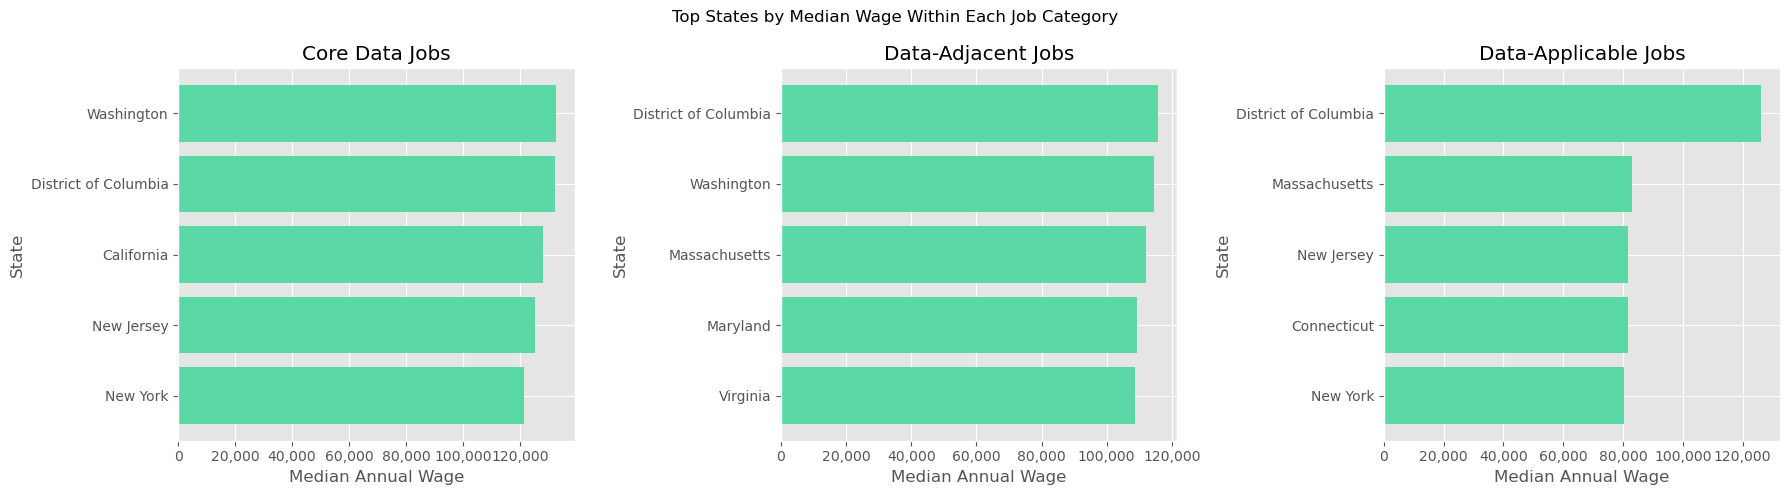

Conclusion:
- Washington offers the highest median wage in Core Data Jobs.
- District of Columbia offers the highest median wage in Data-Adjacent Jobs.
- District of Columbia offers the highest median wage in Data-Applicable Jobs.


In [18]:
top_state_wage = (
    state_category_summary
    .sort_values(['job_category', 'A_MEDIAN'], ascending=[True, False])
    .groupby('job_category')
    .head(5)
)

categories = list(job_categories.keys())
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, category in zip(axes, categories):
    subset = top_state_wage[top_state_wage['job_category'] == category].sort_values('A_MEDIAN')
    ax.barh(subset['AREA_TITLE'], subset['A_MEDIAN'], color='#5AD8A6')
    ax.set_title(category)
    ax.set_xlabel('Median Annual Wage')
    ax.set_ylabel('State')
    ax.xaxis.set_major_formatter(FuncFormatter(comma_format))
fig.suptitle('Top States by Median Wage Within Each Job Category')
plt.tight_layout()
plt.show()

leaders = top_state_wage.sort_values(['job_category', 'A_MEDIAN'], ascending=[True, False]).groupby('job_category').head(1)
print('Conclusion:')
for _, row in leaders.iterrows():
    print(f"- {row['AREA_TITLE']} offers the highest median wage in {row['job_category']}.")

### Q18. Which states seem more balanced for each category?
Use a simple score combining employment and employment-weighted median wage.


In [19]:
state_category_balance = state_category_summary.copy()
state_category_balance['emp_score'] = state_category_balance.groupby('job_category')['TOT_EMP'].transform(lambda s: s / s.max() * 100)
state_category_balance['wage_score'] = state_category_balance.groupby('job_category')['A_MEDIAN'].transform(lambda s: s / s.max() * 100)
state_category_balance['balance_score'] = (state_category_balance['emp_score'] + state_category_balance['wage_score']) / 2

for category in job_categories:
    print(f'\nMost balanced states for {category}:')
    print(
        state_category_balance[state_category_balance['job_category'] == category]
        .sort_values('balance_score', ascending=False)
        .head(5)[['AREA_TITLE', 'TOT_EMP', 'A_MEDIAN', 'balance_score']]
        .to_string(index=False)
    )


Most balanced states for Core Data Jobs:
AREA_TITLE  TOT_EMP      A_MEDIAN  balance_score
California  65120.0 128152.868550      98.348612
     Texas  49420.0 107856.898017      78.636823
  New York  35930.0 121364.467019      73.375063
Washington  18190.0 132530.038483      63.966523
  Virginia  24710.0 118665.907797      63.742104

Most balanced states for Data-Adjacent Jobs:
AREA_TITLE  TOT_EMP      A_MEDIAN  balance_score
California 391720.0 107648.448126      96.450906
  New York 231310.0 106686.477022      75.560726
     Texas 224110.0  91708.700638      68.178708
  Virginia 152670.0 108693.946420      66.389178
   Florida 214770.0  86858.625041      64.893695

Most balanced states for Data-Applicable Jobs:
          AREA_TITLE   TOT_EMP      A_MEDIAN  balance_score
          California 1289730.0  75383.245641      79.867451
               Texas 1235900.0  68712.590744      75.137613
             Florida  902050.0  62371.214456      59.682477
            New York  673950.0  8049

### Q19. How can the most balanced states be visualized?
Show the top balanced states using the combined score.


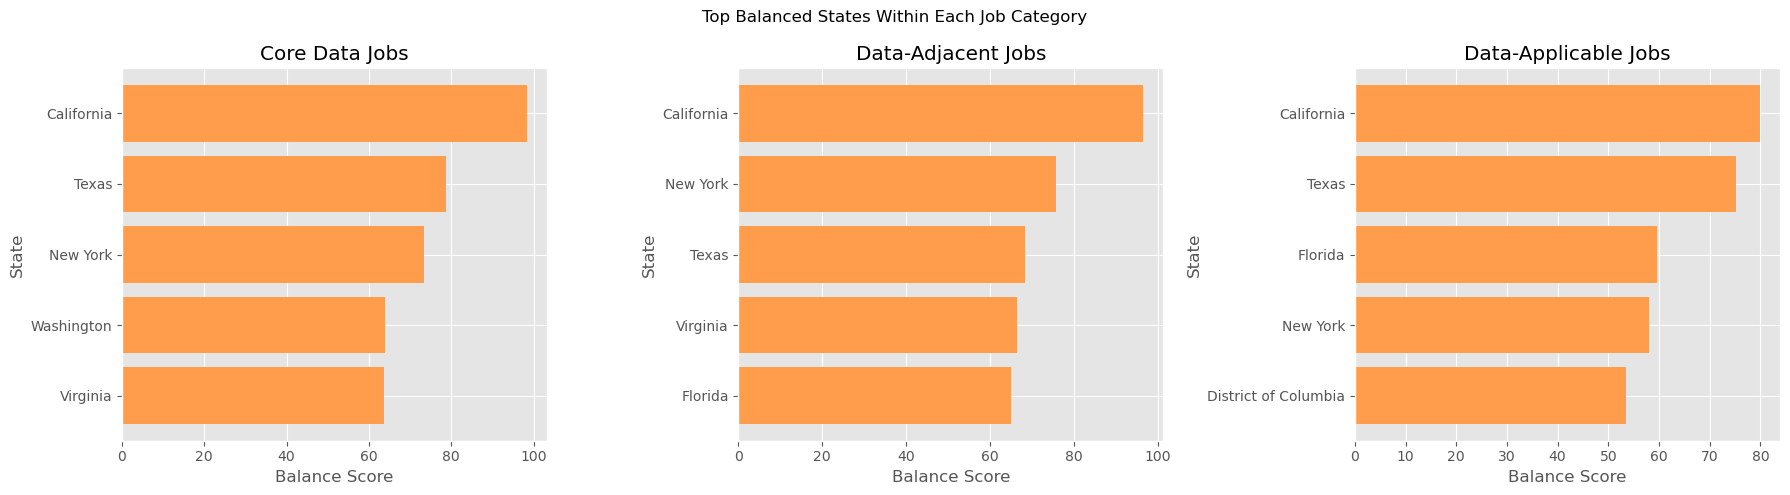

Conclusion:
- California looks like the strongest balanced option for Core Data Jobs.
- California looks like the strongest balanced option for Data-Adjacent Jobs.
- California looks like the strongest balanced option for Data-Applicable Jobs.


In [20]:
top_balance = (
    state_category_balance
    .sort_values(['job_category', 'balance_score'], ascending=[True, False])
    .groupby('job_category')
    .head(5)
)

categories = list(job_categories.keys())
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, category in zip(axes, categories):
    subset = top_balance[top_balance['job_category'] == category].sort_values('balance_score')
    ax.barh(subset['AREA_TITLE'], subset['balance_score'], color='#FF9D4D')
    ax.set_title(category)
    ax.set_xlabel('Balance Score')
    ax.set_ylabel('State')
fig.suptitle('Top Balanced States Within Each Job Category')
plt.tight_layout()
plt.show()

leaders = top_balance.sort_values(['job_category', 'balance_score'], ascending=[True, False]).groupby('job_category').head(1)
print('Conclusion:')
for _, row in leaders.iterrows():
    print(f"- {row['AREA_TITLE']} looks like the strongest balanced option for {row['job_category']}.")

### Q20. Which job category has the highest job density?
Compare summed category `JOBS_1000` across states to see which categories are more concentrated in local labor markets.


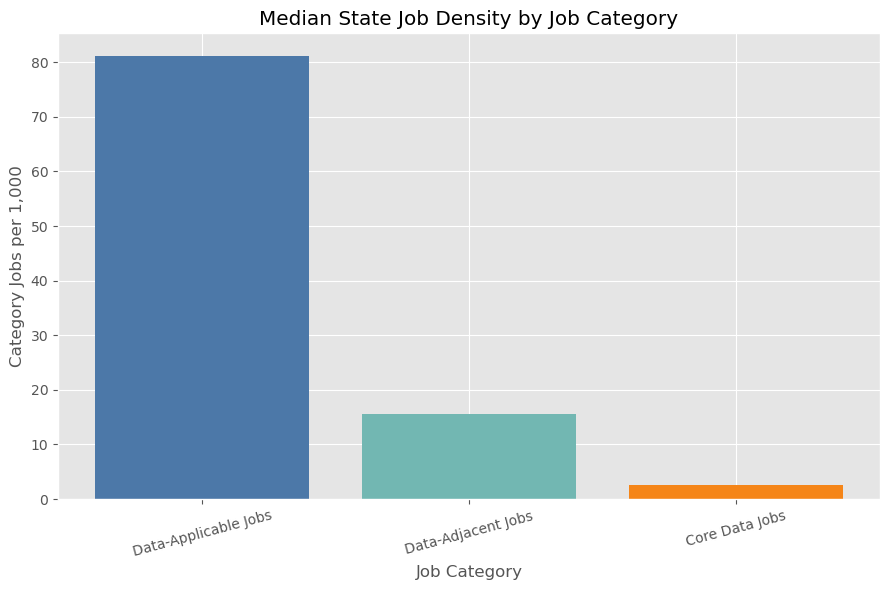

Conclusion:
Data-Applicable Jobs has the highest median state job density. This means it has a stronger presence relative to overall employment, not just a high raw job count.


In [21]:
density_by_category = (
    state_category_summary.groupby('job_category', as_index=False)['JOBS_1000']
    .median()
    .sort_values('JOBS_1000', ascending=False)
)

plt.figure(figsize=(9, 6))
plt.bar(density_by_category['job_category'], density_by_category['JOBS_1000'], color=['#4C78A8', '#72B7B2', '#F58518'])
plt.title('Median State Job Density by Job Category')
plt.xlabel('Job Category')
plt.ylabel('Category Jobs per 1,000')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

leader = density_by_category.iloc[0]
print('Conclusion:')
print(
    f"{leader['job_category']} has the highest median state job density. "
    "This means it has a stronger presence relative to overall employment, not just a high raw job count."
)


## Part 5: Practical Job Search Takeaways
This part turns the category results into more practical job search ideas. Instead of only asking which category is bigger, it looks at specific occupations and less obvious state options.


### Q21. Which specific occupations create the most practical opportunities?
Compare occupations by total employment and lower-end wage. This helps show which job titles may be worth searching for first.


In [22]:
role_summary = summarize_weighted(jobs_by_category, ['job_category', 'OCC_TITLE'])
states_by_role = jobs_by_category.groupby(['job_category', 'OCC_TITLE'], as_index=False).agg(
    states_covered=('AREA_TITLE', 'nunique')
)
role_summary = role_summary.merge(states_by_role, on=['job_category', 'OCC_TITLE'], how='left')

role_summary['employment_rank'] = role_summary.groupby('job_category')['TOT_EMP'].rank(ascending=False, method='first')
role_summary['entry_wage_rank'] = role_summary.groupby('job_category')['A_PCT10'].rank(ascending=False, method='first')
role_summary['practical_rank_score'] = role_summary['employment_rank'] + role_summary['entry_wage_rank']

practical_roles = (
    role_summary
    .sort_values(['job_category', 'practical_rank_score'])
    .groupby('job_category')
    .head(3)
)

print(practical_roles[['job_category', 'OCC_TITLE', 'TOT_EMP', 'A_MEDIAN', 'A_PCT10', 'states_covered']].to_string(index=False))

print()
print('Conclusion:')
print('The most practical roles are not always the highest-paying roles. A useful search list should include jobs with both enough openings and reasonable lower-end wages.')


        job_category                                  OCC_TITLE   TOT_EMP      A_MEDIAN      A_PCT10  states_covered
      Core Data Jobs                            Data Scientists  234350.0 115879.884949 66479.662547              52
      Core Data Jobs                        Database Architects   64430.0 136361.650554 83487.154157              51
      Core Data Jobs                    Database Administrators   73330.0 104455.011591 57666.416201              52
  Data-Adjacent Jobs                  Computer Systems Analysts  499030.0 106363.075767 65850.501573              53
  Data-Adjacent Jobs                        Management Analysts  897610.0 100817.288335 60736.733270              54
  Data-Adjacent Jobs          Financial and Investment Analysts  342060.0 101258.846289 65212.459727              53
Data-Applicable Jobs            General and Operations Managers 3595110.0 105480.124586 49620.001140              54
Data-Applicable Jobs           Administrative Services Managers 

### Q22. How do specific occupations compare on employment and entry-level wage?
Use a scatter plot to compare job volume with `A_PCT10`. This gives a more useful view for job seekers who care about both access and pay.


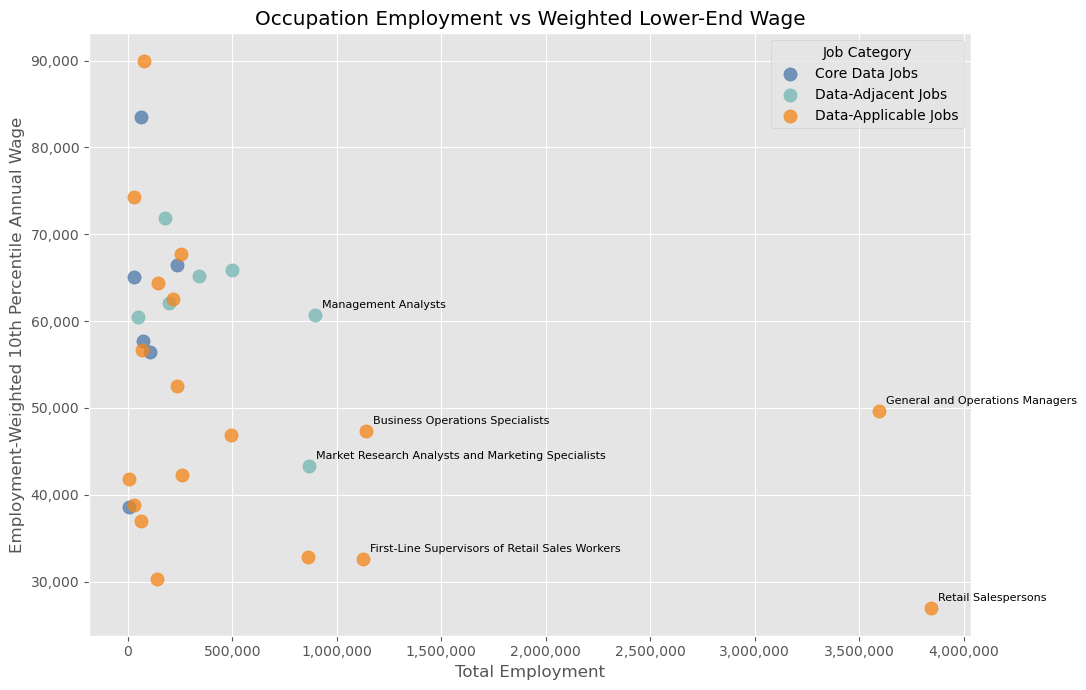

Conclusion:
This chart is more useful than only ranking states. It shows which job titles combine real job volume with a stronger lower-end wage, which is closer to an entry-level job search question.


In [23]:
plt.figure(figsize=(11, 7))
colors = {'Core Data Jobs': '#4C78A8', 'Data-Adjacent Jobs': '#72B7B2', 'Data-Applicable Jobs': '#F58518'}

for category, group in role_summary.groupby('job_category'):
    plt.scatter(group['TOT_EMP'], group['A_PCT10'], label=category,
                color=colors.get(category), s=90, alpha=0.75)

for _, row in role_summary.sort_values('TOT_EMP', ascending=False).head(6).iterrows():
    label = row['OCC_TITLE'].replace(', All Other', '')
    plt.annotate(label, (row['TOT_EMP'], row['A_PCT10']), fontsize=8, xytext=(5, 5), textcoords='offset points')

plt.title('Occupation Employment vs Weighted Lower-End Wage')
plt.xlabel('Total Employment')
plt.ylabel('Employment-Weighted 10th Percentile Annual Wage')
plt.gca().xaxis.set_major_formatter(FuncFormatter(comma_format))
plt.gca().yaxis.set_major_formatter(FuncFormatter(comma_format))
plt.legend(title='Job Category')
plt.tight_layout()
plt.show()

print('Conclusion:')
print('This chart is more useful than only ranking states. It shows which job titles combine real job volume with a stronger lower-end wage, which is closer to an entry-level job search question.')


### Q23. Which states look like hidden opportunities?
A hidden opportunity is not necessarily the biggest market. Here, I look for states with above-median employment and strong location quotient, while excluding the top five employment states in each category.


In [24]:
hidden_options = []
for category in job_categories:
    subset = state_category_summary[state_category_summary['job_category'] == category].copy()
    employment_cutoff = subset['TOT_EMP'].median()
    largest_states = set(subset.sort_values('TOT_EMP', ascending=False).head(5)['AREA_TITLE'])
    hidden = (
        subset[(subset['TOT_EMP'] >= employment_cutoff) & (~subset['AREA_TITLE'].isin(largest_states))]
        .sort_values('LOC_QUOTIENT', ascending=False)
        .head(5)
    )
    hidden_options.append(hidden)

hidden_options = pd.concat(hidden_options, ignore_index=True)
print(hidden_options[['job_category', 'AREA_TITLE', 'TOT_EMP', 'A_MEDIAN', 'A_PCT10', 'LOC_QUOTIENT']].to_string(index=False))

print()
print('Conclusion:')
print('Some states are not the biggest job markets, but they have a stronger concentration of selected roles. These places may be worth checking because applicants may find a more focused local market.')

        job_category           AREA_TITLE  TOT_EMP      A_MEDIAN      A_PCT10  LOC_QUOTIENT
      Core Data Jobs District of Columbia   7730.0 132307.451488 77756.287193      3.537141
      Core Data Jobs             Maryland  14920.0 119268.840483 68861.575067      2.499739
      Core Data Jobs        Massachusetts  20650.0 119683.317191 75967.239709      1.804015
      Core Data Jobs           Washington  18190.0 132530.038483 82611.495327      1.738340
      Core Data Jobs            Tennessee   7720.0  92851.567358 52721.696891      1.653277
  Data-Adjacent Jobs District of Columbia  35830.0 115873.357522 76792.779793      3.857019
  Data-Adjacent Jobs        Massachusetts 116900.0 111972.777588 68732.996578      1.687865
  Data-Adjacent Jobs             Maryland  72350.0 109432.774015 66301.932274      1.580441
  Data-Adjacent Jobs             Colorado  74060.0  98835.116122 60247.261680      1.463824
  Data-Adjacent Jobs           Washington  94290.0 114582.927140 67602.140206   

### Q24. How can hidden opportunity states be visualized?
Plot hidden opportunity states by location quotient. Higher values suggest stronger local concentration for that job category.


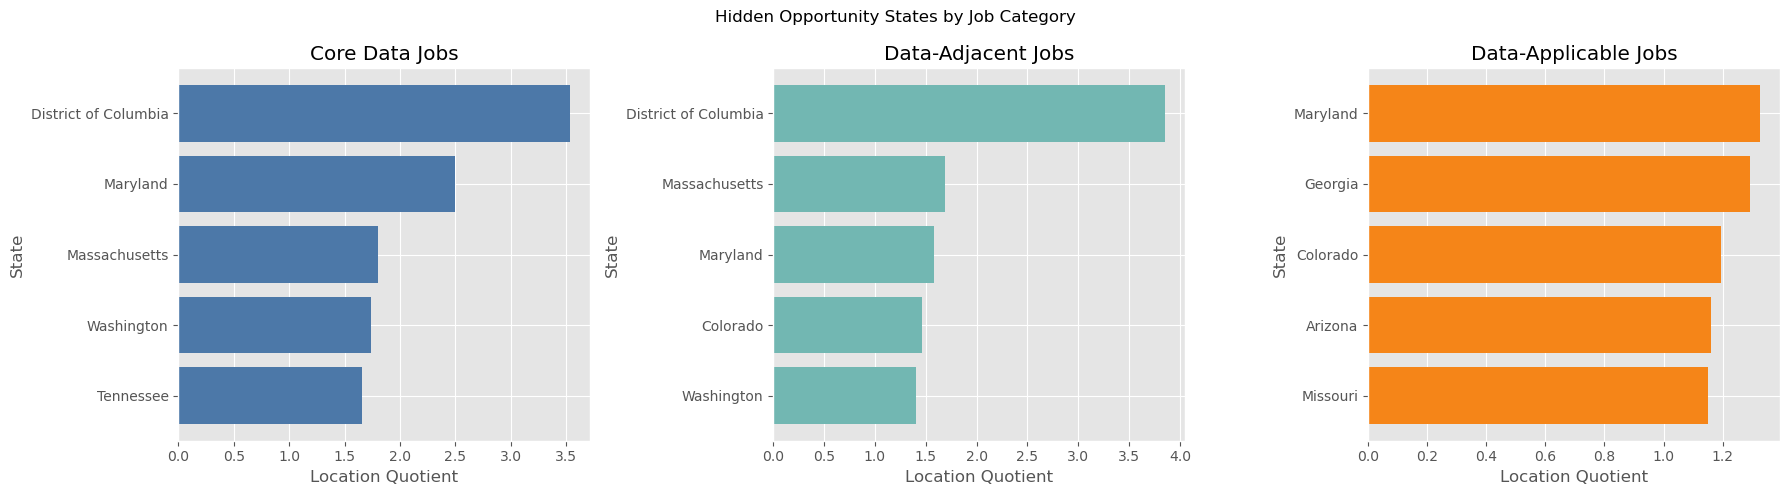

Conclusion:
This chart adds a different kind of takeaway: the best search locations are not only the largest states. Some smaller markets may be more concentrated in a specific type of data-skill job.


In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
categories = list(job_categories.keys())
for ax, category in zip(axes, categories):
    subset = hidden_options[hidden_options['job_category'] == category].sort_values('LOC_QUOTIENT')
    ax.barh(subset['AREA_TITLE'], subset['LOC_QUOTIENT'], color=colors.get(category, '#4C78A8'))
    ax.set_title(category)
    ax.set_xlabel('Location Quotient')
    ax.set_ylabel('State')
fig.suptitle('Hidden Opportunity States by Job Category')
plt.tight_layout()
plt.show()

print('Conclusion:')
print('This chart adds a different kind of takeaway: the best search locations are not only the largest states. Some smaller markets may be more concentrated in a specific type of data-skill job.')

## Part 6: Final Insight


### Q25. What is the best strategy for job seekers with data skills?
Use the category results to think about which types of jobs may be worth targeting.


In [27]:
top_emp_category = employment_by_category.iloc[0]['job_category']
top_median_category = wage_by_category.sort_values('A_MEDIAN', ascending=False).iloc[0]['job_category']
top_pct10_category = wage_by_category.sort_values('A_PCT10', ascending=False).iloc[0]['job_category']

final_insight = f"""
The three job categories show different strengths.

{top_emp_category} has the largest number of jobs, so it gives job seekers the broadest set of openings.
{top_median_category} has the highest employment-weighted median pay, so it may be better for people who want stronger long-term earnings.
{top_pct10_category} has the strongest employment-weighted 10th percentile wage, so it is still important to include wage quality when comparing categories.

Based on this, people with data skills should not search only for one job title. Looking across all three categories can create more options, especially when practical business and operations roles are included.
"""

print(final_insight)



The three job categories show different strengths.

Data-Applicable Jobs has the largest number of jobs, so it gives job seekers the broadest set of openings.
Core Data Jobs has the highest employment-weighted median pay, so it may be better for people who want stronger long-term earnings.
Core Data Jobs has the strongest employment-weighted 10th percentile wage, so it is still important to include wage quality when comparing categories.

Based on this, people with data skills should not search only for one job title. Looking across all three categories can create more options, especially when practical business and operations roles are included.

